In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [2]:
from matplotlib import font_manager

font_dirs = ['/home/shenm19/arial-font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'

In [3]:
df1 = pd.read_csv('experiment_metrics_fully_parallel/default1.csv')
df2 = pd.read_csv('experiment_metrics_fully_parallel/default2.csv')
df3 = pd.read_csv('experiment_metrics_fully_parallel/default3.csv')

# Use index instead of step
for df in [df1, df2, df3]:
    df['index'] = df.index

print(df1.columns)

Index(['equiv/t=0.99/pct_loss_from_equiv_error', 'equiv/t=0.4/mean_grad_norm',
       'equiv/t=0.99/grad_norm_ratio_equiv_over_mean',
       'equiv/t=0.99/total_mse', 'equiv/t=0.9/equiv_error',
       'validation_loss/auxiliary_loss_no_w_epoch', 'scaling/nparams',
       'train/loss_epoch', 'train/auxiliary_loss_step',
       'equiv/t=0.2/mean_grad_norm', 'equiv/t=0.4/mean_pred_error',
       'equiv/t=0.95/grad_norm_ratio_equiv_over_mean', 'train/trans_loss_step',
       'equiv/t=0.6/equiv_grad_norm', 'equiv/t=0/mean_grad_norm',
       'equiv/t=0.6/mean_pred_error', 'validation_loss/trans_loss_step',
       'equiv/t=0.4/pct_loss_from_equiv_error',
       'equiv/t=0.9/pct_loss_from_equiv_error', 'equiv/t=0.99/mean_pred_error',
       'equiv/t=0.95/pct_loss_from_equiv_error', 'train/dist_mat_loss_epoch',
       'validation_loss/distogram_loss_epoch', 'equiv/t=0.6/total_mse',
       'train/auxiliary_loss_no_w_epoch', 'train/dist_mat_loss_step',
       'equiv/t=0.8/equiv_error', 'equiv/t=0

In [ ]:
mdf = pd.merge(df1, df2, on=['_step'], suffixes=('_1', '_2'))
df3_renamed = df3.copy().rename(columns={c: f'{c}_3' for c in df3.columns if c != '_step'})
mdf = pd.merge(mdf, df3_renamed, on=['_step'], suffixes=('', '_3'))
mdf.columns

In [ ]:
cols = ['index'] + [col for col in df1.columns if col.startswith('equiv/t=') and col.endswith('pct_loss_from_equiv_error')]

df1[cols].dropna().reset_index(drop=True).set_index('index')

,equiv/t=0.99/pct_loss_from_equiv_error,equiv/t=0.4/pct_loss_from_equiv_error,equiv/t=0.9/pct_loss_from_equiv_error,equiv/t=0.95/pct_loss_from_equiv_error,equiv/t=0/pct_loss_from_equiv_error,equiv/t=0.6/pct_loss_from_equiv_error,equiv/t=0.2/pct_loss_from_equiv_error,equiv/t=0.8/pct_loss_from_equiv_error
index,,,,,,,,
113,0.106436,0.106420,0.110051,0.108772,0.101503,0.109629,0.105373,0.113418
227,0.083048,0.082495,0.083820,0.082784,0.079702,0.083705,0.080784,0.082842
341,0.062965,0.068058,0.066055,0.061759,0.062143,0.069561,0.065833,0.066980
455,0.049204,0.052704,0.049048,0.048548,0.048714,0.051647,0.051179,0.049718
569,0.036701,0.040688,0.036432,0.036884,0.036855,0.038705,0.038972,0.035944
...,...,...,...,...,...,...,...,...
702046,0.031280,0.015470,0.047992,0.045791,0.000298,0.020415,0.010429,0.034718
702160,0.032804,0.015887,0.049272,0.047790,0.000332,0.023615,0.005290,0.034052
702274,0.029487,0.017040,0.048808,0.047003,0.000333,0.026131,0.007091,0.035056


### plot replicates (not finalized)

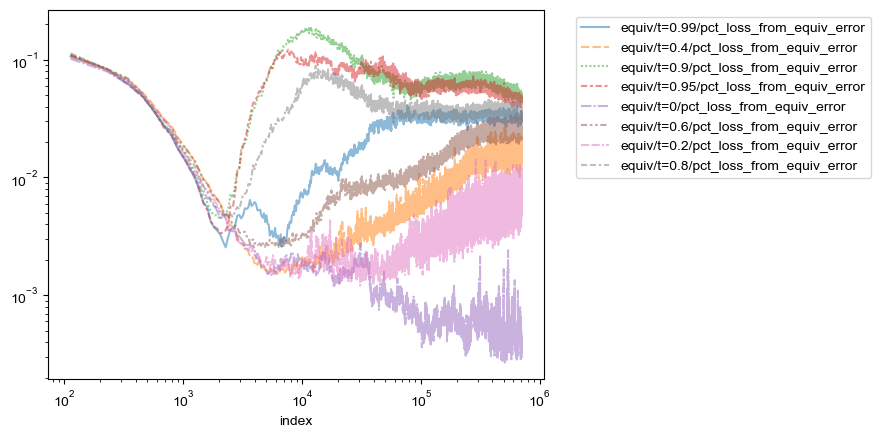

In [6]:
sns.lineplot(
    data = df1[cols].dropna().reset_index(drop=True).set_index('index'),
    # hue = ''
    # color = '#00a0dc',
    errorbar = None,
    alpha=0.5,
    sort = False,
)

plt.yscale('log')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()

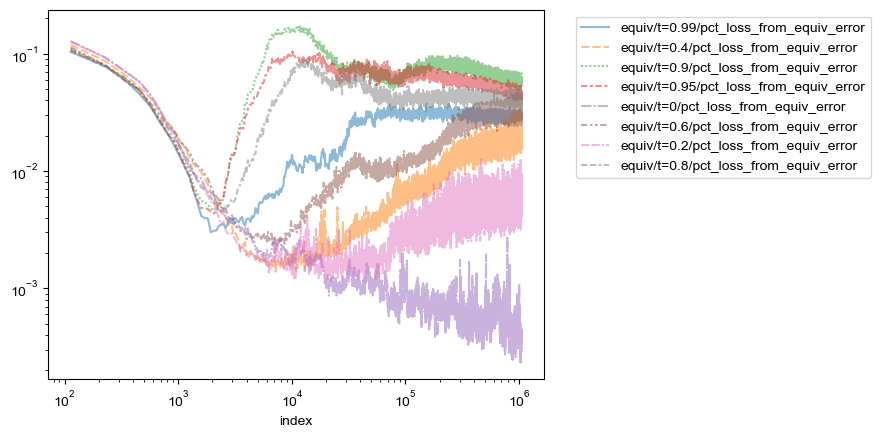

In [7]:
sns.lineplot(
    data = df2[cols].dropna().reset_index(drop=True).set_index('index'),
    # hue = ''
    # color = '#00a0dc',
    errorbar = None,
    alpha=0.5,
    sort = False,
)

plt.yscale('log')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()

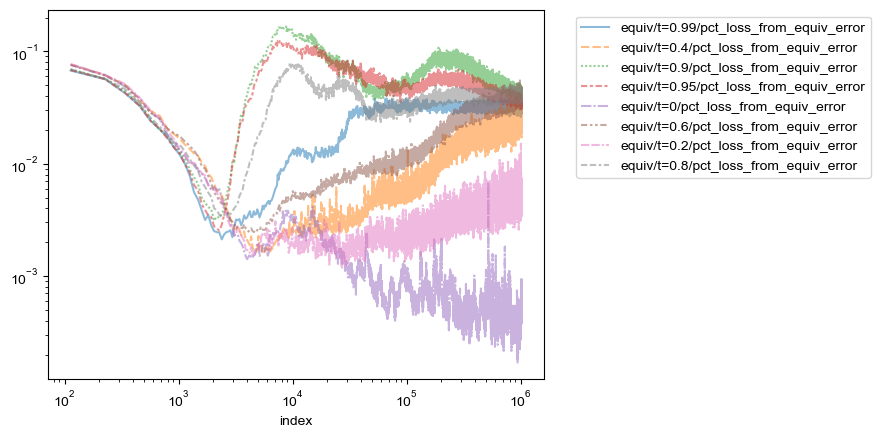

In [8]:
sns.lineplot(
    data = df3[cols].dropna().reset_index(drop=True).set_index('index'),
    # hue = ''
    # color = '#00a0dc',
    errorbar = None,
    alpha=0.5,
    sort = False,
)

plt.yscale('log')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()

### plot with smoothing

In [ ]:
def variable_span_ema(data: pd.Series, span_scale_factor: int = 1000) -> pd.Series:
    """
    Calculates an EMA with a span that increases with the index value (timestep).

    Args:
        data (pd.Series): The input data to smooth. Must have a numeric index (e.g., timesteps).
        span_scale_factor (int): Controls how quickly the span grows. A larger value
                                 means the span grows slower, resulting in less smoothing.
                                 The span at a given timestep `x` is roughly `x / span_scale_factor`.

    Returns:
        pd.Series: The smoothed data with the same index as the input.
    """
    if data.empty:
        return data

    # Get index and values for faster iteration
    index = data.index.to_numpy()
    values = data.to_numpy()
    
    # Initialize the output array and the first EMA value
    ema_values = np.zeros_like(values)
    ema_values[0] = values[0] 

    # Iterate from the second point onwards
    for i in range(1, len(values)):
        current_step = index[i]
        
        # 1. Calculate the variable span. Ensure it's at least 1.
        span = max(1.0, current_step / span_scale_factor)
        
        # 2. Convert span to alpha
        alpha = 2.0 / (span + 1.0)
        
        # 3. Apply the EMA formula
        ema_values[i] = alpha * values[i] + (1 - alpha) * ema_values[i-1]
        
    return pd.Series(ema_values, index=data.index)


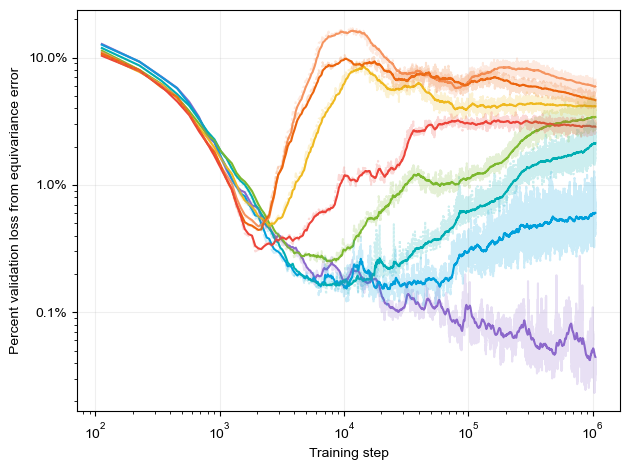

In [24]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

plot_df = df2[cols].dropna().reset_index(drop=True).set_index('index')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/pct_loss_from_equiv_error', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['index'], var_name = 'time', value_name = 'pct_loss_from_equiv_error')

fig, ax = plt.subplots()
sns.lineplot(
    data = melted_smoothed_plot_df,
    x = 'index',
    y = 'pct_loss_from_equiv_error',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    legend = False,
    alpha=1.0,
    ax = ax,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
    ax = ax,
)
# ax.get_legend().remove()

plt.yscale('log')
plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Percent validation loss from equivariance error');

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plot_name = f"prot_60M"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()

In [ ]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

plot_df = df2[cols].dropna().reset_index(drop=True).set_index('index')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/pct_loss_from_equiv_error', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['index'], var_name = 'time', value_name = 'pct_loss_from_equiv_error')

fig, ax = plt.subplots()
sns.lineplot(
    data = melted_smoothed_plot_df,
    x = 'index',
    y = 'pct_loss_from_equiv_error',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    legend = False,
    alpha=1.0,
    ax = ax,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
    ax = ax,
)
# ax.get_legend().remove()

# plt.yscale('log')
# plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Percent validation loss from equivariance error');

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plot_name = f"prot_60M"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
# plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
# plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()

### plot final % equiv error by time

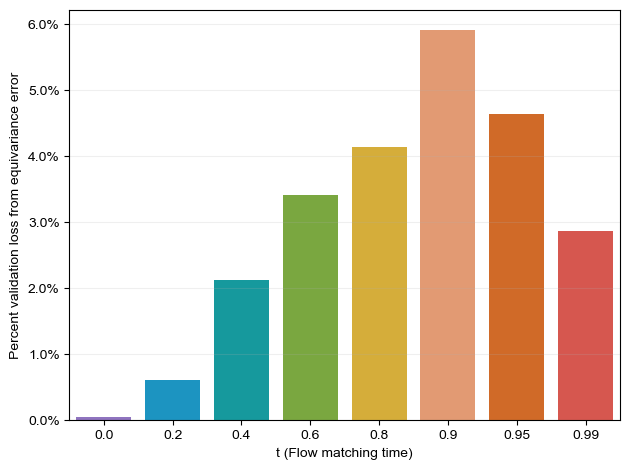

In [11]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

plot_df = df2[cols].dropna().reset_index(drop=True).set_index('index')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/pct_loss_from_equiv_error', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['index'], var_name = 'time', value_name = 'pct_loss_from_equiv_error')

final_idx_df = smoothed_plot_df.iloc[-1].to_frame(name = 'pct_loss_from_equiv_error')
final_idx_df['Time'] = [float(t.replace('t=', '')) for t in final_idx_df.index]
final_idx_df['Time string'] = final_idx_df.index
final_idx_df

fig, ax = plt.subplots()
sns.barplot(
    data = final_idx_df,
    x = 'Time',
    y = 'pct_loss_from_equiv_error',
    hue = 'Time string',
    palette=color_palette,
    legend = False,
    ax = ax,
)
# sns.lineplot(
#     data = final_idx_df,
#     x = 'Time',
#     y = 'pct_loss_from_equiv_error',
#     hue = 'Time string',
#     errorbar = None,
#     marker = 'o',
#     palette=color_palette,
#     linestyle='-',
#     legend = False,
#     ax = ax,
# )
plt.grid(axis = 'y', alpha = 0.2)
# sns.lineplot(
#     data = plot_df,
#     errorbar = None,
#     palette=color_palette,
#     alpha=0.2,
#     legend=False,
# )

plt.xlabel(f't (Flow matching time)');
plt.ylabel(f'Percent validation loss from equivariance error');
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plot_name = f"prot_60M_final_step"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()

### loss curves

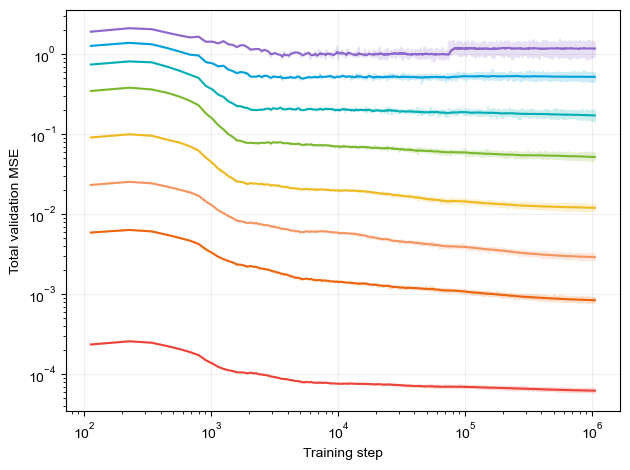

In [21]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

total_mse_cols = ['index'] + [col for col in df1.columns if col.startswith('equiv/t=') and col.endswith('total_mse')]

plot_df = df2[total_mse_cols].dropna().reset_index(drop=True).set_index('index')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/total_mse', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['index'], var_name = 'time', value_name = 'total_mse')

sns.lineplot(
    data = melted_smoothed_plot_df,
    x = 'index',
    y = 'total_mse',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    alpha=1.0,
    legend = False,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
)

plt.yscale('log')
plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Total validation MSE');

# plt.savefig('prot_60M-total-mse.png', bbox_inches='tight', dpi=300)
# plt.show()
# plt.close()

plot_name = f"prot_60M-total-mse"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()

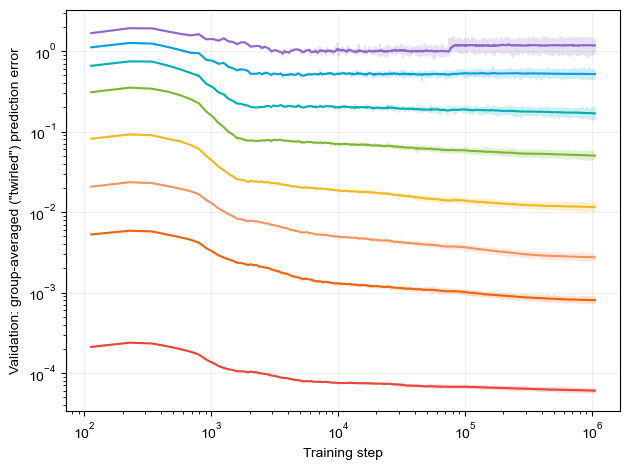

In [22]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

mean_pred_error_cols = ['index'] + [col for col in df1.columns if col.startswith('equiv/t=') and col.endswith('mean_pred_error')]

plot_df = df2[mean_pred_error_cols].dropna().reset_index(drop=True).set_index('index')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/mean_pred_error', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['index'], var_name = 'time', value_name = 'mean_pred_error')

sns.lineplot(
    data = melted_smoothed_plot_df,
    x = 'index',
    y = 'mean_pred_error',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    alpha=1.0,
    legend = False,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
)

plt.yscale('log')
plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Validation: group-averaged ("twirled") prediction error');

# plt.savefig('prot_60M-mean-pred-error.png', bbox_inches='tight', dpi=300)
# plt.show()
# plt.close()

plot_name = f"prot_60M-mean-pred-error"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()

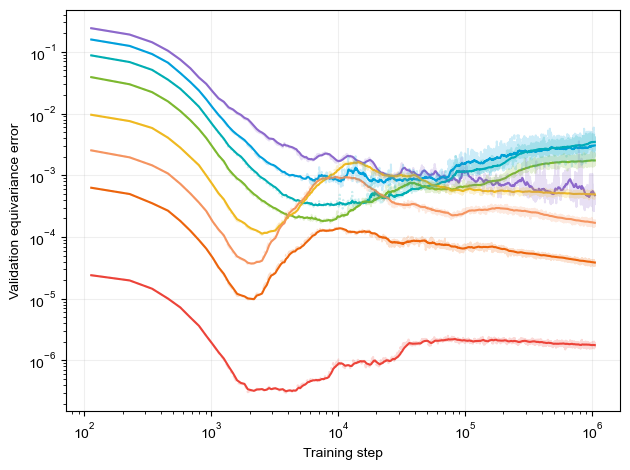

In [23]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

equiv_error_cols = ['index'] + [col for col in df1.columns if col.startswith('equiv/t=') and col.endswith('/equiv_error')]

plot_df = df2[equiv_error_cols].dropna().reset_index(drop=True).set_index('index')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/equiv_error', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['index'], var_name = 'time', value_name = 'equiv_error')

sns.lineplot(
    data = melted_smoothed_plot_df,
    x = 'index',
    y = 'equiv_error',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    alpha=1.0,
    legend = False,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
)

plt.yscale('log')
plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Validation equivariance error');

# plt.savefig('prot_60M-equiv-error.png', bbox_inches='tight', dpi=300)
# plt.show()
# plt.close()

plot_name = f"prot_60M-equiv-error"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()

### step vs. index

<Axes: xlabel='index', ylabel='_step'>

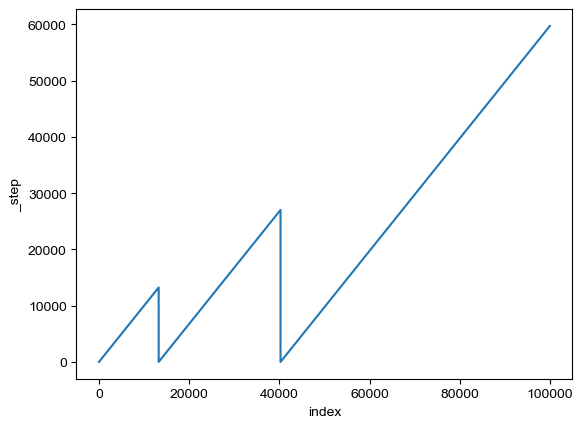

In [15]:
df3['index'] = df3.index
sns.lineplot(
    data = df3[df3['index'] < 100_000],
    x = 'index',
    y = '_step',
    sort = False,
    errorbar = None,
)